In [14]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

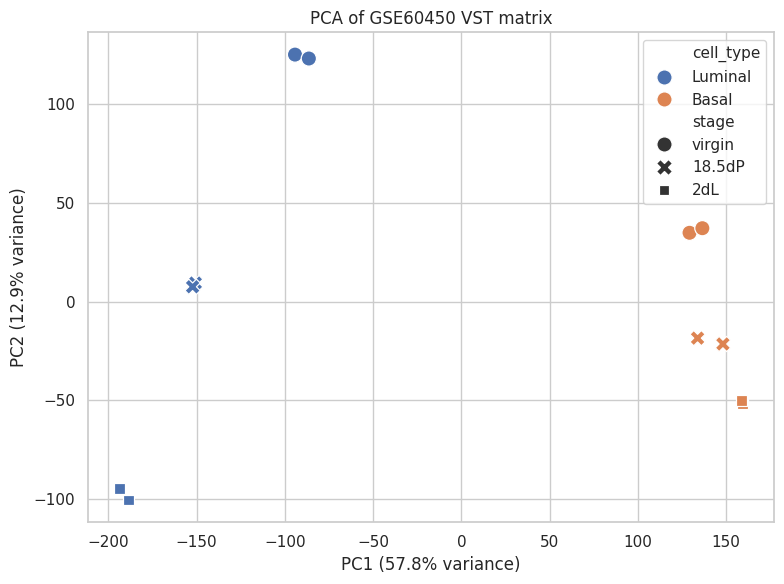

In [15]:
# load transformed data (VST or rlog)
project_root = Path.cwd().parent
vst_matrix = pd.read_csv(project_root / "quants" / "GSE60450_vst_matrix.csv", index_col=0) 
metadata = pd.read_csv(project_root / "quants" / "GSE60450_metadata.csv", index_col=0)

# perform PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(vst_matrix)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=vst_matrix.index).join(metadata)

# plot PCA
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cell_type", style="stage", s=120)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of GSE60450 VST matrix")
plt.tight_layout()
plt.show()


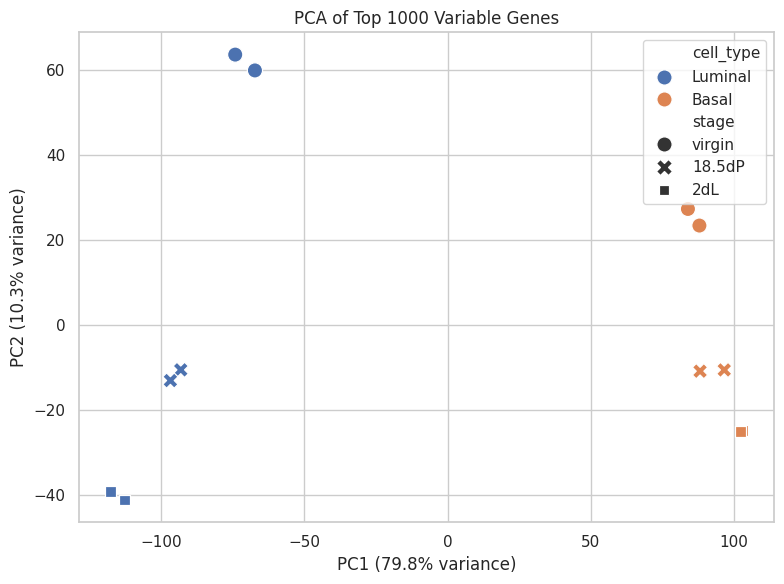

In [20]:
# select top 1000 most variable genes 
top_n = 1000
gene_var = vst_matrix.var(axis=0) 
top_genes = gene_var.nlargest(top_n).index
vst_matrix_top = vst_matrix[top_genes]

# perform PCA on top variable genes
pca_top = PCA(n_components=2)
pcs_top = pca_top.fit_transform(vst_matrix_top)
pca_top_df = pd.DataFrame(pcs_top, columns=["PC1", "PC2"], index=vst_matrix_top.index).join(metadata)

#plot PCA of top variable genes
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_top_df, x="PC1", y="PC2", hue="cell_type", style="stage", s=120)
plt.xlabel(f"PC1 ({pca_top.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_top.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of Top 1000 Variable Genes")
plt.tight_layout()
plt.show()